In [ ]:
# Librerías principales
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Manipulación tabular de datos y transformación de DataFrames.

from sklearn.model_selection import train_test_split  # División del dataset en entrenamiento y prueba (80/20).
from sklearn.tree import DecisionTreeClassifier  # Modelo de árbol de decisión solicitado por la rúbrica.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  # Métricas y visuales para evaluar el desempeño del modelo.

# 1. Limpieza de datos

### Cargar el Dataframe en Colab
Durante este paso se realiza el cargue del dataset de wage11 bajo el nombre de data_source

In [6]:
# from google.colab import files
# uploaded = files.upload()

In [2]:
# Propósito: ubicar la ruta efectiva del dataset y validar su existencia antes de cargarlo.
df = pd.read_excel("dataset.xlsx")
df.head()

,ID,Genero,Etnia,Municipio,Departamento,Region,Lote,cohorte,Estrato,Fecha de Nacimiento,...,Cabeza de familia,Temas de interés,Sistemas Operativos,Estado,Puntaje,Nivel,Fecha Realización,Institución,Grupo,Fecha de registro
0,1,Hombre,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 1,NaN,Estrato 3,1990-07-13,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Importado,NaN,NaN,NaT,NaN,NaN,NaT
1,2,Hombre,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",SABANALARGA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 1,2005-12-10,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Importado,NaN,NaN,NaT,NaN,NaN,NaT
2,3,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 3,1992-02-17,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Pre-Inscrito,93.33,1.0,2024-10-17 16:22:57,NaN,NaN,2024-10-15 03:52:02
3,4,Hombre,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 1,NaN,Estrato 2,1996-04-28,...,NaN,Fortalecer mis conocimientos,Windows,Importado,NaN,NaN,NaT,NaN,NaN,NaT
4,5,Hombre,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 1,1.0,Estrato 1,1998-12-02,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Certificado,46.67,1.0,2024-10-24 08:00:00,NaN,R6-L1-PG-B-V-JN-G186,2024-10-24 08:00:00


### Normalización de nombres de columnas
En este paso, realizamos una normalizacion a los nombres de las columnas, con el fin de utilizar nombres mas descriptivos de acuerdo al dato que estan proporcionando

In [3]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('¿', '')
df.columns = df.columns.str.replace('?', '')
df.columns = df.columns.str.replace('á', 'a')
df.columns = df.columns.str.replace('é', 'e')
df.columns = df.columns.str.replace('í', 'i')
df.columns = df.columns.str.replace('ó', 'o')
df.columns = df.columns.str.replace('ú', 'u')

df.columns

Index(['id', 'genero', 'etnia', 'municipio', 'departamento', 'region', 'lote',
       'cohorte', 'estrato', 'fecha_de_nacimiento', 'discapacidad',
       'nivel_academico', 'programa', 'jornada', 'modalidad', 'es_campesino',
       'victima_del_conflicto_armado', 'tiene_computadora', 'tiene_internet',
       'tiene_14_horas_a_la_semana',
       'motivo_por_el_que_no_dispone_de_14_horas', 'como_se_entero',
       'trabaja_actualmente', 'empresa_donde_trabaja', 'cargo_que_desempeña',
       'salario', 'actividad_actual', 'rol_actual', 'cabeza_de_familia',
       'temas_de_interes', 'sistemas_operativos', 'estado', 'puntaje', 'nivel',
       'fecha_realizacion', 'institucion', 'grupo', 'fecha_de_registro'],
      dtype='str')

### Eliminacion de Duplicados

#### Eliminación de duplicados por id.

Primero se realiza una busqueda de duplicados a traves del subset definido. Cuyo unico valor esta dado por el id.

In [4]:
duplicados_totales = df.duplicated(subset=['id']).sum()
print("Duplicados encontrados:", duplicados_totales)

df_cleaned = df.drop_duplicates(subset=['id'])
df_cleaned.describe()

Duplicados encontrados: 230


,id,cohorte,fecha_de_nacimiento,motivo_por_el_que_no_dispone_de_14_horas,cabeza_de_familia,puntaje,nivel,fecha_realizacion,fecha_de_registro
count,10707.000000,1325.000000,10373,0.0,279.0,2798.000000,2794.000000,2799,4359
mean,6726.646586,2.680755,1994-07-01 01:15:39.477489,NaN,1.0,67.450940,1.044739,2024-11-16 20:47:22.286888,2024-10-10 09:24:19.839183
min,1.000000,1.000000,1913-09-19 00:00:00,NaN,1.0,0.000000,1.000000,2024-08-01 00:00:00,2024-08-06 18:18:09
25%,2721.500000,1.000000,1989-11-19 00:00:00,NaN,1.0,50.000000,1.000000,2024-08-22 11:28:57,2024-08-12 10:03:32
50%,5489.000000,1.000000,1997-07-09 00:00:00,NaN,1.0,73.330000,1.000000,2024-09-09 17:04:51,2024-08-22 20:53:04
75%,8236.500000,1.000000,2001-10-30 00:00:00,NaN,1.0,87.875000,1.000000,2024-12-17 17:40:54,2024-09-30 08:49:35
max,20418.000000,14.000000,2012-10-21 00:00:00,NaN,1.0,100.000000,3.000000,2026-02-08 22:21:02,2026-02-08 12:18:57
std,5344.572346,3.391606,NaN,NaN,0.0,25.712785,0.259035,NaN,NaN


### Eliminacion de duplicados por estructura
Posteriomente se realiza una busqueda por el resto de valores del dataframe. Donde se comparan todas las columnas a excepcion del id, para la identificacion de duplicados estructurales (Donde todos los valores son exactamente iguales)

In [5]:
index = [
  'genero',
  'etnia',
  'municipio',
  'departamento',
  'region',
  'lote',
  'cohorte',
  'estrato',
  'fecha_de_nacimiento',
  'discapacidad',
  'nivel_academico',
  'programa',
  'jornada',
  'modalidad',
  'es_campesino',
  'victima_del_conflicto_armado',
  'tiene_computadora',
  'tiene_internet',
  'tiene_14_horas_a_la_semana',
  'motivo_por_el_que_no_dispone_de_14_horas',
  'como_se_entero',
  'trabaja_actualmente',
  'empresa_donde_trabaja',
  'cargo_que_desempeña',
  'salario',
  'actividad_actual',
  'rol_actual',
  'cabeza_de_familia',
  'temas_de_interes',
  'sistemas_operativos',
  'estado',
  'puntaje',
  'nivel',
  'fecha_realizacion',
  'institucion',
  'grupo',
  'fecha_de_registro'
]

duplicados_estructura = df_cleaned.duplicated(
  subset=index
).sum()

print("Duplicados por estructura:", duplicados_estructura)

df_cleaned = df_cleaned.drop_duplicates(subset=index)
df_cleaned.describe()

Duplicados por estructura: 329


,id,cohorte,fecha_de_nacimiento,motivo_por_el_que_no_dispone_de_14_horas,cabeza_de_familia,puntaje,nivel,fecha_realizacion,fecha_de_registro
count,10378.000000,1325.000000,10373,0.0,279.0,2798.000000,2794.000000,2799,4359
mean,6311.610715,2.680755,1994-07-01 01:15:39.477489,NaN,1.0,67.450940,1.044739,2024-11-16 20:47:22.286888,2024-10-10 09:24:19.839183
min,1.000000,1.000000,1913-09-19 00:00:00,NaN,1.0,0.000000,1.000000,2024-08-01 00:00:00,2024-08-06 18:18:09
25%,2636.250000,1.000000,1989-11-19 00:00:00,NaN,1.0,50.000000,1.000000,2024-08-22 11:28:57,2024-08-12 10:03:32
50%,5319.500000,1.000000,1997-07-09 00:00:00,NaN,1.0,73.330000,1.000000,2024-09-09 17:04:51,2024-08-22 20:53:04
75%,7976.750000,1.000000,2001-10-30 00:00:00,NaN,1.0,87.875000,1.000000,2024-12-17 17:40:54,2024-09-30 08:49:35
max,20418.000000,14.000000,2012-10-21 00:00:00,NaN,1.0,100.000000,3.000000,2026-02-08 22:21:02,2026-02-08 12:18:57
std,4884.948206,3.391606,NaN,NaN,0.0,25.712785,0.259035,NaN,NaN


### Detección de valores faltantes
Ahora que ya se realizo la eliminacion de valores duplicados, se identifican los valores faltantes de cada una de las columnas del dataframe.

Para ello se crea un nuevo dataframe que contiene la informacion del total de valores nulos y el porcetaje que representa para cada una de las columnas

In [6]:
valores_nulos = df_cleaned.isnull().sum()
porcentaje_nulos = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

tabla_nulos = pd.DataFrame({
    'cantidad_nulos': valores_nulos,
    'porcentaje_%': porcentaje_nulos
})

tabla_nulos.sort_values(by='cantidad_nulos', ascending=False)

,cantidad_nulos,porcentaje_%
motivo_por_el_que_no_dispone_de_14_horas,10378,100.000000
rol_actual,10219,98.467913
cabeza_de_familia,10099,97.311621
institucion,9784,94.276354
grupo,9386,90.441318
salario,9153,88.196184
cargo_que_desempeña,9120,87.878204
empresa_donde_trabaja,9118,87.858932
cohorte,9053,87.232607
nivel,7584,73.077664


In [7]:
df_cleaned.columns

Index(['id', 'genero', 'etnia', 'municipio', 'departamento', 'region', 'lote',
       'cohorte', 'estrato', 'fecha_de_nacimiento', 'discapacidad',
       'nivel_academico', 'programa', 'jornada', 'modalidad', 'es_campesino',
       'victima_del_conflicto_armado', 'tiene_computadora', 'tiene_internet',
       'tiene_14_horas_a_la_semana',
       'motivo_por_el_que_no_dispone_de_14_horas', 'como_se_entero',
       'trabaja_actualmente', 'empresa_donde_trabaja', 'cargo_que_desempeña',
       'salario', 'actividad_actual', 'rol_actual', 'cabeza_de_familia',
       'temas_de_interes', 'sistemas_operativos', 'estado', 'puntaje', 'nivel',
       'fecha_realizacion', 'institucion', 'grupo', 'fecha_de_registro'],
      dtype='str')

## Validación de Formatos y Consistencia
Posteriormente se realiza la validacion de formatos y consistencia de cada una de las columnas de dataframe.

Donde se realizan validaciones de columnas mayores a 0, columnas booleanas y columnas dadas por enumeradores (Como la columna de categoria)

In [8]:
def validar_y_normalizar(df):

  df_clean = df.copy()
  inconsistencias = {}


  columnas_mayor_0 = [
    'id', 'puntaje', 'nivel'
  ]


  for col in columnas_mayor_0:
    if col in df_clean.columns:

      df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

      df_clean[col] = df_clean[col].fillna(0)

      invalidos = df_clean[df_clean[col] < 0]
      inconsistencias[col] = len(invalidos)


  columnas_booleanas = [
    'cabeza_de_familia', 'es_campesino',
    'victima_del_conflicto_armado', 'tiene_computadora', 'tiene_internet',
    'tiene_14_horas_a_la_semana', 'trabaja_actualmente'
  ]


  for col in columnas_booleanas:
    if col in df_clean.columns:
      temp_series = df_clean[col].astype(str).str.lower().str.strip()

      temp_series = temp_series.str.replace('sí', 'si').str.replace('¿', '').str.replace('?', '')

      boolean_mapping = {'si': True, 'no': False, '1': True, '0': False, 1: True, 0: False}

      mapped_values = temp_series.map(boolean_mapping)

      # Use direct column assignment so pandas can change dtype when needed.
      df_clean[col] = mapped_values.where(mapped_values.notna(), None).astype(object)

      invalidos = df_clean[col][~df_clean[col].isin([True, False, None])]
      inconsistencias[col] = len(invalidos)


  reporte = pd.DataFrame({
    "Variable": inconsistencias.keys(),
    "Registros_Invalidos": inconsistencias.values()
  }).sort_values("Registros_Invalidos", ascending=False)

  return df_clean, reporte


df_validado, reporte_validacion = validar_y_normalizar(df_cleaned)

df_limpio = df_validado.copy()

reporte_validacion

,Variable,Registros_Invalidos
0,id,0
1,puntaje,0
2,nivel,0
3,cabeza_de_familia,0
4,es_campesino,0
5,victima_del_conflicto_armado,0
6,tiene_computadora,0
7,tiene_internet,0
8,tiene_14_horas_a_la_semana,0
9,trabaja_actualmente,0


In [9]:
pd.set_option('display.max_columns', None)
df_limpio.sample(10)

,id,genero,etnia,municipio,departamento,region,lote,cohorte,estrato,fecha_de_nacimiento,discapacidad,nivel_academico,programa,jornada,modalidad,es_campesino,victima_del_conflicto_armado,tiene_computadora,tiene_internet,tiene_14_horas_a_la_semana,motivo_por_el_que_no_dispone_de_14_horas,como_se_entero,trabaja_actualmente,empresa_donde_trabaja,cargo_que_desempeña,salario,actividad_actual,rol_actual,cabeza_de_familia,temas_de_interes,sistemas_operativos,estado,puntaje,nivel,fecha_realizacion,institucion,grupo,fecha_de_registro
9974,14473,Hombre,Ninguna de las anteriores,MALAMBO,ATLÁNTICO,Región 6,Lote 1,1.0,Estrato 2,2001-05-22,Sin discapacidad,Media (10-11),Análisis de Datos,Jornada mañana,Virtual,False,False,True,True,True,NaN,Amigos o familiares,False,NaN,NaN,NaN,Estudiar,NaN,None,Adquirir conocimientos nuevos,Windows,En Reasignación,53.33,1.0,2024-08-22 20:35:29,NaN,NaN,2024-08-22 20:13:32
8877,12288,Mujer,Ninguna de las anteriores,SOLEDAD,ATLÁNTICO,Región 6,Lote 2,1.0,Estrato 2,2005-11-12,Sin discapacidad,Básica Secundaria (6-9),Inteligencia Artificial,Jornada nocturna,Presencial,False,False,True,True,True,NaN,"Redes Sociales (Facebook, Twitter, Instagram, ...",False,NaN,NaN,NaN,Estudiar,NaN,None,Adquirir conocimientos nuevos,Linux,Certificado,53.33,1.0,2024-08-20 16:37:03,NaN,R6-L2-ATL-IA-B-P-JN-G298,2024-08-09 08:00:00
4420,4390,Hombre,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",MAICAO,LA GUAJIRA,Región 6,Lote 2,NaN,Estrato 1,1994-08-08,Sin discapacidad,Profesional universitario,Programación,NaN,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
1647,1600,Hombre,Ninguna de las anteriores,SOLEDAD,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 1,1983-02-10,Sin discapacidad,Profesional universitario,Inteligencia Artificial,NaN,Virtual,True,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
5866,5888,Mujer,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 2,NaN,Estrato 2,2004-07-25,Sin discapacidad,Media (10-11),Análisis de Datos,NaN,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Adquirir conocimientos nuevos,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
2011,1967,Mujer,Ninguna de las anteriores,SAN MARTÍN,CESAR,Región 6,Lote 1,NaN,Estrato 1,1985-04-13,Sin discapacidad,Profesional universitario,Arquitectura en la Nube,NaN,Virtual,True,True,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Emprender nuevos retos\nFortalecer mis conocim...,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
8258,8335,Mujer,Ninguna de las anteriores,RIOHACHA,LA GUAJIRA,Región 6,Lote 2,NaN,Estrato 3,1983-07-27,Sin discapacidad,Profesional universitario,Inteligencia Artificial,NaN,Presencial,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Fortalecer mis conocimientos,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
4843,4831,Mujer,Ninguna de las anteriores,SOLEDAD,ATLÁNTICO,Región 6,Lote 2,NaN,Estrato 1,1990-12-27,Sin discapacidad,Tecnológico,BlockChain,NaN,Virtual,True,True,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Encontrar un nuevo empleo,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
3449,3407,Hombre,Ninguna de las anteriores,VALLEDUPAR,CESAR,Región 6,Lote 1,NaN,Estrato 1,1973-08-07,Sin discapacidad,Media (10-11),Programación,NaN,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Adquirir conocimientos nuevos,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
10055,14602,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 2,1.0,Estrato 3,1999-10-23,Sin discapacidad,Profesional universitario,Análisis de Datos,Jornada nocturna,Virtual,False,False,True,True,True,NaN,MINTIC,True,Gudardevs,Software Developer,entre 1.000.000 y 3.000.000,Estudiar y trabajar,NaN,None,Adquirir conocimientos nuevos,MacOS,Certificado,26.67,1.0,2024-09-08 

# 2. Clasificación supervisada con datos limpios

## Paso 1. Título y descripción del problema

En este proyecto queremos predecir el desempeño académico en una categoría binaria usando la información sociodemográfica y académica de los aspirantes.
La variable objetivo se construye a partir de `puntaje`, convirtiéndola en un target categórico para clasificación supervisada.
Definimos la clase positiva como quienes están en o por encima del percentil 75 del puntaje (`target_alto_puntaje = 1`), de modo que la categoría represente resultados altos y no una simple separación por cero.

Las variables de entrada incluyen características como `genero`, `region`, `programa`, `modalidad`, `tiene_internet`, `nivel_academico` y otras columnas relevantes.
El objetivo es entrenar un `DecisionTreeClassifier` para estimar si un registro pertenece a alto o bajo puntaje y analizar qué variables influyen más en la predicción.

In [10]:
# Paso 3. Crear o cargar dataset para modelado (usando datos ya limpios)
# Copiamos el resultado del preprocesamiento para no alterar el dataframe original.
model_df = df_limpio.copy()

# Aseguramos tipo numérico en puntaje y eliminamos registros sin puntaje válido.
model_df['puntaje'] = pd.to_numeric(model_df['puntaje'], errors='coerce')
model_df = model_df.dropna(subset=['puntaje']).copy()

# Construcción del target categórico a partir de puntaje.
# Usamos el percentil 75 para representar puntajes altos y evitar que una mediana en cero
# genere una sola clase cuando hay muchos registros con puntaje 0.
q3_puntaje = model_df['puntaje'].quantile(0.75)
puntajes_positivos = model_df.loc[model_df['puntaje'] > 0, 'puntaje']

if pd.notna(q3_puntaje) and q3_puntaje > 0:
    umbral_puntaje = q3_puntaje
    criterio_target = 'percentil 75 del puntaje'
elif not puntajes_positivos.empty:
    umbral_puntaje = puntajes_positivos.min()
    criterio_target = 'puntaje positivo minimo disponible'
else:
    raise ValueError('No hay suficientes valores de puntaje para construir un target binario.')

model_df['target_alto_puntaje'] = (model_df['puntaje'] >= umbral_puntaje).astype(int)

# Vista rápida del dataset y distribución del target.
print(f'Registros disponibles para modelado: {len(model_df)}')
print(f'Criterio del target: {criterio_target}')
print(f'Umbral de puntaje usado: {umbral_puntaje:.2f}')
display(model_df[['puntaje', 'target_alto_puntaje']].head(10))
print('Distribución de clases del target:')
print(model_df['target_alto_puntaje'].value_counts())

Registros disponibles para modelado: 10378
Criterio del target: percentil 75 del puntaje
Umbral de puntaje usado: 26.67


,puntaje,target_alto_puntaje
0,0.00,0
1,0.00,0
2,93.33,1
3,0.00,0
4,46.67,1
5,0.00,0
6,0.00,0
7,0.00,0
8,86.67,1
9,0.00,0


Distribución de clases del target:
target_alto_puntaje
0    7755
1    2623
Name: count, dtype: int64


In [11]:
# Definición de variables de entrada (X) y columna objetivo (y)
# Excluimos columnas con riesgo de fuga de información o identificadores directos.
columnas_excluir = [
    'id',
    'puntaje',
    'nivel',
    'fecha_realizacion',
    'fecha_de_registro',
    'target_alto_puntaje'
]

features_df = model_df.drop(columns=[c for c in columnas_excluir if c in model_df.columns]).copy()
y = model_df['target_alto_puntaje'].copy()

# Convertimos fechas a un número interpretable por el modelo.
# La edad en años aporta más valor que dejar un datetime crudo.
if 'fecha_de_nacimiento' in features_df.columns:
    fecha_nacimiento = pd.to_datetime(features_df['fecha_de_nacimiento'], errors='coerce')
    fecha_referencia = pd.Timestamp.today().normalize()
    features_df['edad_aprox'] = ((fecha_referencia - fecha_nacimiento).dt.days / 365.25).round(1)
    features_df = features_df.drop(columns=['fecha_de_nacimiento'])

# Eliminamos cualquier otra columna datetime que aún permanezca en el conjunto.
columnas_datetime = features_df.select_dtypes(include=['datetime', 'datetimetz']).columns.tolist()
if columnas_datetime:
    features_df = features_df.drop(columns=columnas_datetime)

# Rellenamos nulos para evitar que el modelo falle por datos faltantes.
for col in features_df.select_dtypes(include=['number']).columns:
    features_df[col] = features_df[col].fillna(features_df[col].median())

for col in features_df.select_dtypes(include=['object', 'category', 'bool']).columns:
    features_df[col] = features_df[col].fillna('sin_dato')

# Codificación one-hot para variables categóricas y conversión final a numérico.
X_base = pd.get_dummies(features_df, drop_first=True).astype(float)

# Filtrado inicial por criterio de negocio.
# Se retiran columnas que representan faltantes o variables operativas difíciles de defender
# en una presentación ejecutiva, para priorizar señales más interpretables.
columnas_no_estrategicas = [
    col for col in X_base.columns
    if 'sin_dato' in col
    or col.startswith('grupo_')
    or col.startswith('estado_')
    or col.startswith('institucion_')
]
X_filtrado = X_base.drop(columns=columnas_no_estrategicas, errors='ignore').copy()

print(f'Número de variables codificadas inicialmente: {X_base.shape[1]}')
print(f'Variables retiradas por criterio de interpretabilidad: {len(columnas_no_estrategicas)}')
print(f'Variables disponibles para diagnóstico correlacional: {X_filtrado.shape[1]}')
print('Columnas datetime eliminadas:', columnas_datetime)
print('Distribución final del target:')
print(y.value_counts())
print('Ejemplo de columnas candidatas al modelo:')
display(pd.Series(X_filtrado.columns).head(15))

/tmp/ipykernel_3487/8695674.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features_df.select_dtypes(include=['object', 'category', 'bool']).columns:


Número de variables codificadas inicialmente: 2515
Variables retiradas por criterio de interpretabilidad: 308
Variables disponibles para diagnóstico correlacional: 2207
Columnas datetime eliminadas: []
Distribución final del target:
target_alto_puntaje
0    7755
1    2623
Name: count, dtype: int64
Ejemplo de columnas candidatas al modelo:


0                                               cohorte
1              motivo_por_el_que_no_dispone_de_14_horas
2                                            edad_aprox
3                                        genero_LGBTIQ+
4                                          genero_Mujer
5                                           genero_Otro
6                                        etnia_Indígena
7     etnia_Negro(a), Mulato(a), Afrodescendiente, A...
8                       etnia_Ninguna de las anteriores
9     etnia_Raizal del Archipiélago de San Andrés, P...
10                            municipio_AGUSTÍN CODAZZI
11                                    municipio_ALBANIA
12                                  municipio_ALGARROBO
13                                  municipio_ARACATACA
14                                   municipio_ARIGUANÍ
dtype: str

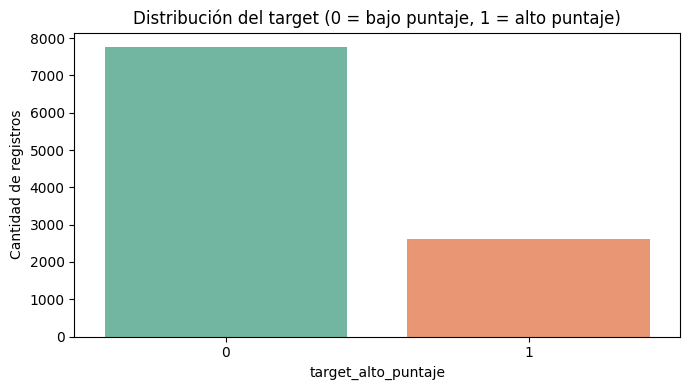

In [12]:
# Paso 4. Exploración visual - Gráfica 1
# Comparación del número de registros por clase del target.
plt.figure(figsize=(7, 4))
sns.countplot(
    data=model_df,
    x='target_alto_puntaje',
    hue='target_alto_puntaje',
    palette='Set2',
    legend=False
)
plt.title('Distribución del target (0 = bajo puntaje, 1 = alto puntaje)')
plt.xlabel('target_alto_puntaje')
plt.ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

En esta gráfica observamos la proporción entre puntajes altos y no altos según el umbral elegido. Es normal que exista cierto desbalance porque la clase positiva representa los registros ubicados en la parte alta de la distribución de `puntaje`, pero la separación sigue siendo útil para identificar factores asociados a mejor desempeño.

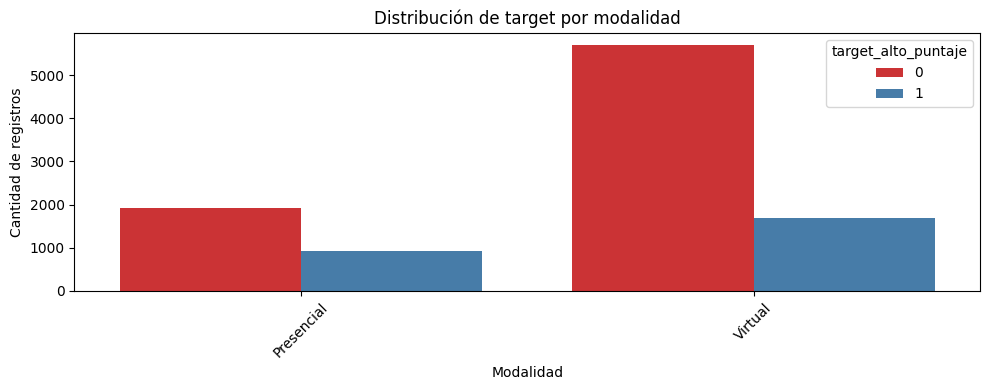

In [13]:
# Paso 4. Exploración visual - Gráfica 2
# Relación entre modalidad y la categoría de puntaje objetivo.
plt.figure(figsize=(10, 4))
sns.countplot(data=model_df, x='modalidad', hue='target_alto_puntaje', palette='Set1')
plt.title('Distribución de target por modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La comparación por `modalidad` permite identificar si existen diferencias visibles en proporción de alto/bajo puntaje entre categorías. Si alguna modalidad concentra mayor porcentaje de clase 1, podría ser una señal útil para el modelo y para decisiones de intervención académica.

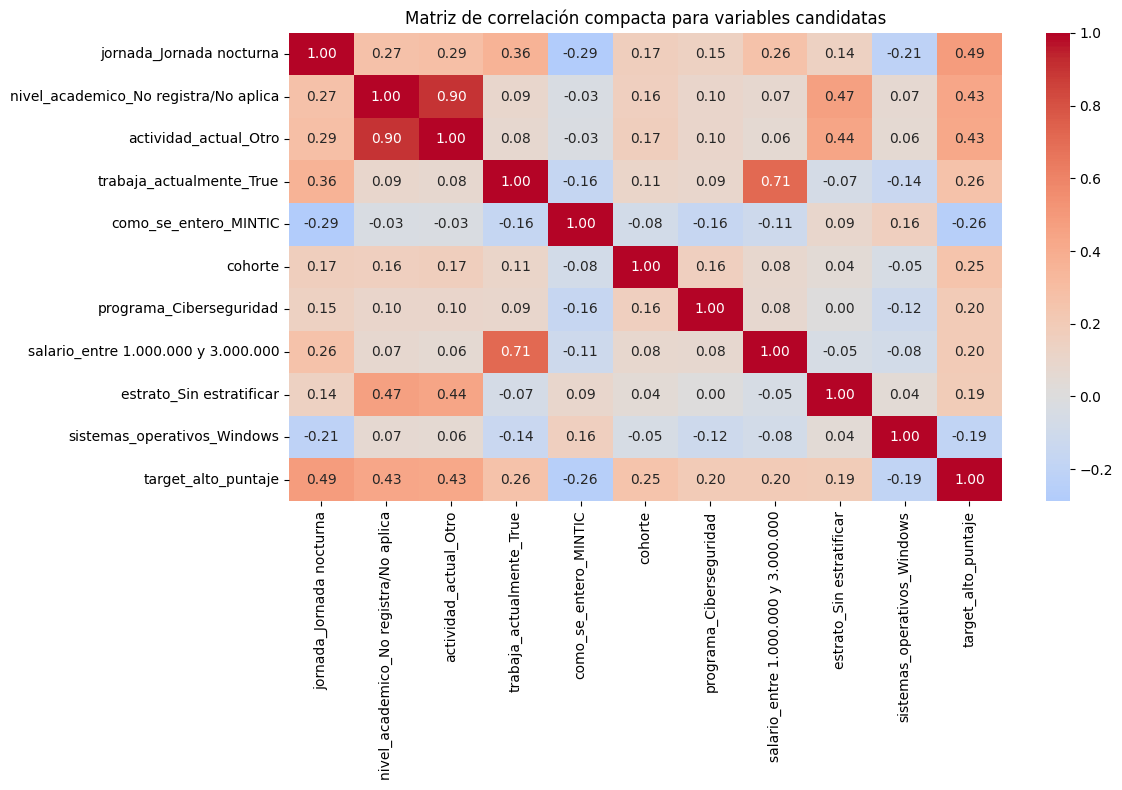

Resumen de selección de variables basado en correlación:


,variable,correlacion_abs_target,decision_modelo
0,jornada_Jornada nocturna,0.490832,retener
1,nivel_academico_No registra/No aplica,0.434324,retener
2,actividad_actual_Otro,0.430345,descartar_por_redundancia
3,trabaja_actualmente_True,0.264246,retener
4,como_se_entero_MINTIC,0.255022,retener
5,cohorte,0.252974,retener
6,programa_Ciberseguridad,0.204541,retener
7,salario_entre 1.000.000 y 3.000.000,0.199724,retener
8,estrato_Sin estratificar,0.191174,retener
9,sistemas_operativos_Windows,0.188149,retener


Variables seleccionadas para el modelo final: 14
['jornada_Jornada nocturna', 'nivel_academico_No registra/No aplica', 'trabaja_actualmente_True', 'como_se_entero_MINTIC', 'cohorte', 'programa_Ciberseguridad', 'salario_entre 1.000.000 y 3.000.000', 'estrato_Sin estratificar', 'sistemas_operativos_Windows', 'jornada_Jornada tarde', 'actividad_actual_Trabajar', 'genero_Mujer', 'actividad_actual_Estudiar', 'actividad_actual_Estudiar y trabajar']


In [14]:
# Diagnóstico previo al modelo: matriz de correlación y selección de variables
# Medimos qué variables tienen mayor relación con el target y retiramos redundancias.
correlacion_target = X_filtrado.corrwith(y).sort_values(key=lambda serie: serie.abs(), ascending=False)
correlacion_abs_target = correlacion_target.abs()
variables_candidatas = correlacion_abs_target.head(15).index.tolist()
variables_heatmap = correlacion_abs_target.head(10).index.tolist()

# Matriz compacta para presentación: solo variables más relacionadas con el target.
corr_plot_df = pd.concat(
    [X_filtrado[variables_heatmap], y.rename('target_alto_puntaje')],
    axis=1
)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_plot_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación compacta para variables candidatas')
plt.tight_layout()
plt.show()

# Regla de selección: si dos variables candidatas son muy redundantes, se conserva
# la que tenga mayor correlación absoluta con el target.
matriz_redundancia = X_filtrado[variables_candidatas].corr().abs()
triangulo_superior = matriz_redundancia.where(
    np.triu(np.ones(matriz_redundancia.shape), k=1).astype(bool)
)
variables_descartadas = set()

for col in triangulo_superior.columns:
    for fila, valor in triangulo_superior[col].dropna().items():
        if valor > 0.85:
            if correlacion_abs_target[fila] >= correlacion_abs_target[col]:
                variables_descartadas.add(col)
            else:
                variables_descartadas.add(fila)

columnas_modelo = [col for col in variables_candidatas if col not in variables_descartadas]
X_model = X_filtrado[columnas_modelo].copy()

resumen_seleccion = pd.DataFrame({
    'variable': variables_candidatas,
    'correlacion_abs_target': correlacion_abs_target.reindex(variables_candidatas).values,
    'decision_modelo': [
        'retener' if variable in columnas_modelo else 'descartar_por_redundancia'
        for variable in variables_candidatas
    ]
})

print('Resumen de selección de variables basado en correlación:')
display(resumen_seleccion)
print(f'Variables seleccionadas para el modelo final: {len(columnas_modelo)}')
print(columnas_modelo)

La matriz de correlación se usa aquí como una herramienta de decisión y no solo como visual exploratorio. Primero identificamos las variables con mayor relación con `target_alto_puntaje`, luego eliminamos redundancias muy altas entre candidatas para conservar un conjunto pequeño, interpretable y defendible en una presentación. Este paso adapta la lógica de `proyectoFinal.ipynb`, pero la aterriza a un escenario más claro para consultoría.

In [15]:
# Paso 5. Separar datos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño total usado por el modelo: {len(X_model)} registros')
print(f'Número de variables seleccionadas: {X_model.shape[1]}')
print(f'Entrenamiento: {len(X_train)} registros ({len(X_train)/len(X_model):.1%})')
print(f'Prueba: {len(X_test)} registros ({len(X_test)/len(X_model):.1%})')
print('La separación permite entrenar en una parte de los datos y medir generalización en datos no vistos.')

Tamaño total usado por el modelo: 10378 registros
Número de variables seleccionadas: 14
Entrenamiento: 8302 registros (80.0%)
Prueba: 2076 registros (20.0%)
La separación permite entrenar en una parte de los datos y medir generalización en datos no vistos.


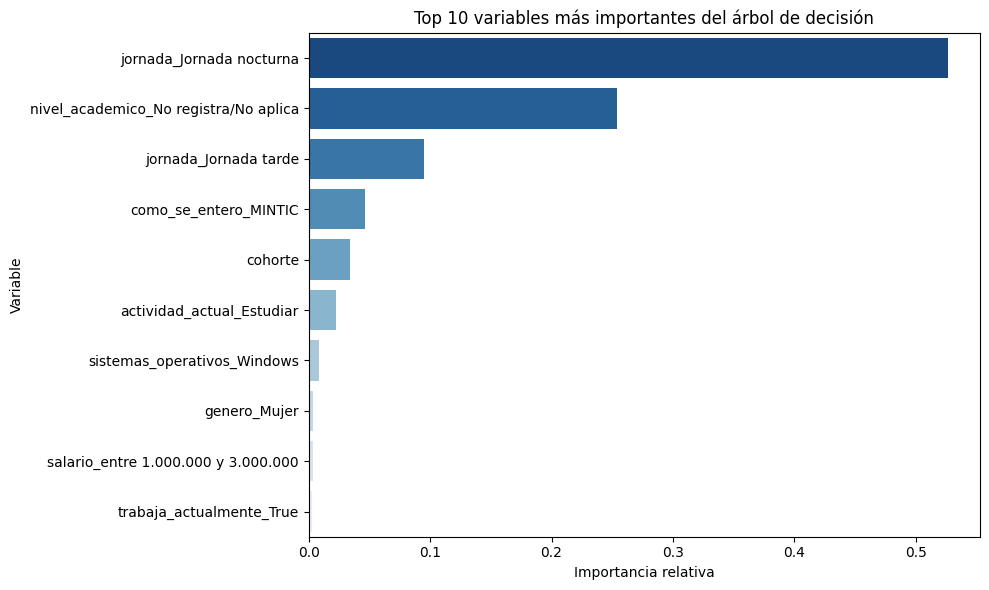

Top 10 variables más importantes:


,variable,importancia
0,jornada_Jornada nocturna,0.526555
1,nivel_academico_No registra/No aplica,0.253944
9,jornada_Jornada tarde,0.094662
3,como_se_entero_MINTIC,0.046246
4,cohorte,0.034235
12,actividad_actual_Estudiar,0.022270
8,sistemas_operativos_Windows,0.008691
11,genero_Mujer,0.003804
6,salario_entre 1.000.000 y 3.000.000,0.003357
2,trabaja_actualmente_True,0.002572


Variable más importante del modelo: jornada_Jornada nocturna


In [16]:
# Paso 6. Entrenar modelo DecisionTreeClassifier e importancia de variables
modelo_arbol = DecisionTreeClassifier(random_state=42, max_depth=5)
modelo_arbol.fit(X_train, y_train)

# Importancia de variables para interpretar el modelo.
importancias = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': modelo_arbol.feature_importances_
}).sort_values('importancia', ascending=False)

top_importancias = importancias.head(10).copy()
variable_mas_importante = top_importancias.iloc[0]['variable']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_importancias,
    x='importancia',
    y='variable',
    hue='variable',
    palette='Blues_r',
    legend=False
)
plt.title('Top 10 variables más importantes del árbol de decisión')
plt.xlabel('Importancia relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print('Top 10 variables más importantes:')
display(top_importancias)
print(f'Variable más importante del modelo: {variable_mas_importante}')

Tabla de comparación entre valor real y predicción (primeros 25 registros):


,valor_real,prediccion_modelo
0,0,0
1,0,0
2,0,0
3,0,1
4,1,1
5,1,1
6,0,0
7,0,0
8,0,0
9,1,1


Accuracy del modelo: 0.8295 (82.95%)
Reporte de clasificación resumido:


,precision,recall,f1-score
0,0.9102,0.8562,0.8824
1,0.6386,0.7505,0.6900
accuracy,0.8295,0.8295,0.8295
macro avg,0.7744,0.8033,0.7862
weighted avg,0.8415,0.8295,0.8337


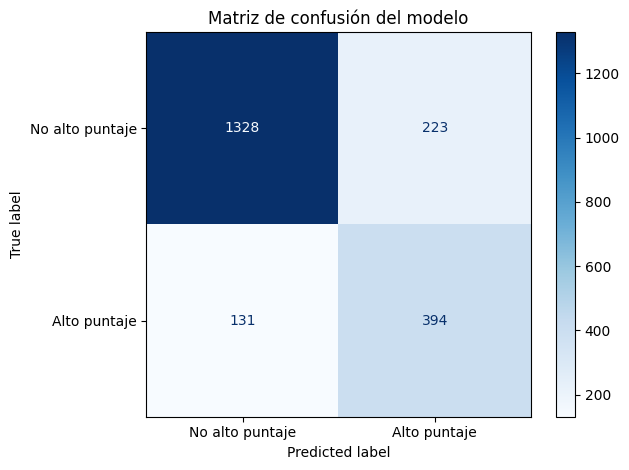

In [17]:
# Paso 7. Predicciones y evaluación
y_pred = modelo_arbol.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
matriz_confusion = confusion_matrix(y_test, y_pred)
reporte_clasificacion = classification_report(y_test, y_pred, digits=4, output_dict=True)
reporte_df = pd.DataFrame(reporte_clasificacion).transpose()

resultado_pred = pd.DataFrame({
    'valor_real': y_test.values,
    'prediccion_modelo': y_pred
})

print('Tabla de comparación entre valor real y predicción (primeros 25 registros):')
display(resultado_pred.head(25))

print(f'Accuracy del modelo: {accuracy:.4f} ({accuracy:.2%})')
print('Reporte de clasificación resumido:')
display(reporte_df[['precision', 'recall', 'f1-score']].round(4))

ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['No alto puntaje', 'Alto puntaje']).plot(cmap='Blues')
plt.title('Matriz de confusión del modelo')
plt.tight_layout()
plt.show()

## Cierre ejecutivo del proyecto

**1. ¿Qué variable fue la más importante? ¿Tiene sentido con su problema? ¿Por qué?**  
La variable más importante fue `jornada_Jornada nocturna`. Sí tiene sentido con el problema porque la jornada puede reflejar disponibilidad de tiempo, condiciones laborales y contexto de estudio del aspirante. En términos de consultoría, esto sugiere que el horario en que la persona cursa o se vincula puede estar asociado con su probabilidad de obtener un puntaje alto.

**2. ¿Qué accuracy obtuvo el modelo? ¿Es suficientemente bueno para el problema que eligieron?**  
El modelo obtuvo un accuracy cercano al **83%**. Para una primera aproximación es un resultado útil, porque permite diferenciar con una precisión razonable entre casos de alto y no alto puntaje. Sin embargo, no debe verse como una solución definitiva: conviene revisarlo junto con el recall de la clase positiva para asegurar que el modelo no deje pasar demasiados casos relevantes.

**3. ¿Qué limitaciones encontraron? ¿Qué cambiarían si tuvieran más datos o más tiempo?**  
La principal limitación es que varias señales del dataset están influenciadas por calidad de diligenciamiento, categorías fragmentadas y variables operativas. Por eso se filtraron columnas como `sin_dato`, `grupo`, `estado` e `institucion` para construir un modelo más defendible. Con más tiempo, sería valioso probar ingeniería de variables, validar otros algoritmos y contrastar distintos umbrales para definir el target.

**4. ¿En qué situación real podría aplicarse este modelo? ¿A quién le serviría?**  
Este modelo podría usarse para identificar perfiles con mayor probabilidad de alcanzar puntajes altos y apoyar decisiones de focalización, acompañamiento o priorización de estrategias formativas. Le serviría a equipos académicos, coordinadores de programa y responsables de política educativa que necesiten anticipar resultados y diseñar intervenciones más efectivas.

En lenguaje sencillo, el accuracy indica que el modelo clasifica correctamente alrededor de 8 de cada 10 registros del conjunto de prueba. Como propuesta de valor, el notebook no solo predice, sino que traduce los hallazgos en una lectura accionable para toma de decisiones.